# 3. Extracción y Limpieza de Alimentos

Este cuaderno implementa un flujo de trabajo optimizado para transformar la base de datos masiva de **Open Food Facts** (alojada en Hugging Face) en un dataset estructurado listo para el modelado de Machine Learning.

---

##  Fases del Proceso

### 1. Extracción de Datos de Alto Rendimiento
Para manejar un volumen de datos tan grande (más de 4 millones de registros originales), se utiliza el formato **Parquet**.
* **Carga Selectiva**: No descargamos todo el archivo; solo extraemos las columnas críticas: `product_name`, `nutriscore_grade`, `nova_group` y `additives_tags`.
* **Fuente**: Se conecta directamente al repositorio oficial en Hugging Face.

In [2]:
# Manipulación de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# URL del archivo Parquet en Hugging Face
url = "https://huggingface.co/datasets/openfoodfacts/product-database/resolve/main/food.parquet?download=true"

# Columnas mínimas necesarias
columns = [
    'code',                 # <--- Clave primaria: El código de barras
    'product_name', 
    'nutriscore_grade', 
    'nova_group', 
    'additives_tags', 
    'ingredients_text',  
    'food_groups_tags'
]

# Carga de dataframe
df_raw = pd.read_parquet(url, columns=columns)

In [12]:
# ==============================================================================
# INGENIERÍA DE TEXTO: APLANAMIENTO DE COLUMNAS MULTIIDIOMA (HUGGING FACE)
# ==============================================================================

def extraer_texto_ingles_prioritario(lista_struct):
    """
    Extrae el texto analítico priorizando el inglés ('en') para mantener
    la consistencia idiomática con el resto del pipeline de la tesis.
    """
    if isinstance(lista_struct, (list, np.ndarray)):
        # Pasada 1: Buscamos si existe la cadena en inglés
        for item in lista_struct:
            if isinstance(item, dict) and item.get('lang') == 'en':
                return item.get('text', '')
        
        # Pasada 2: Fallback al español si el producto es local y no se tradujo
        for item in lista_struct:
            if isinstance(item, dict) and item.get('lang') == 'es':
                return item.get('text', '')
                
    return ''

# Aplicamos la extracción para transformar los 'struct' anidados en strings limpios
df_raw['product_name_limpio'] = df_raw['product_name'].apply(extraer_texto_ingles_prioritario)
df_raw['ingredients_text_raw'] = df_raw['ingredients_text'].apply(extraer_texto_ingles_prioritario)

# Sobrescribimos las columnas viejas con las limpias para no arrastrar basura en memoria
df_raw = df_raw.drop(columns=['product_name', 'ingredients_text'])
df_raw = df_raw.rename(columns={
    'product_name_limpio': 'product_name',
    'ingredients_text_raw': 'ingredients_text'
})

print("✨ [PROCESAMIENTO] Columnas 'product_name' e 'ingredients_text' aplanadas con éxito.")

✨ [PROCESAMIENTO] Columnas 'product_name' e 'ingredients_text' aplanadas con éxito.


### 2. Limpieza y Filtrado de Calidad
El dataset crudo contiene mucho "ruido" (valores nulos o inconsistentes). Se aplican tres filtros de limpieza:
* **Validación de Nutriscore**: Se conservan únicamente los productos con calificaciones reales entre la **'a'** y la **'e'**.
* **Validación de NOVA**: Se filtran los grupos de procesamiento para que estén estrictamente en el rango del **1 al 4**.
* **Normalización de Aditivos**: Se transforman los valores nulos en listas vacías (`[]`).

> **Resultado del filtrado**: Se obtiene un dataset limpio de aproximadamente **836,199 productos**.

VEMOS LA DISTRIBUCION POR CATEGORIAS DEL DATASET CRUDO Y LIMPIO PARA VER SI TRAS LA LIMPIEZA SE ALTERA LA REPRESENTATIVIDAD DE CADA CATEGORIA; Y QUITAMOS BEBIDAS ALCOHOLICAS YA QUE QUEDAN FUERA DEL OBJETIVO DE ESTE TRABAJO

             RESUMEN MÉTRICO DEL DATASET              
Total productos en df_raw (sin alcohol): 4429011
Total productos en df_clean (filtrado) : 837908
Productos sin aditivos (Grupo Control) : 342783

--- TABLA COMPARATIVA DE DISTRIBUCIÓN POR CATEGORÍA ---


,Cantidad Antes,% Antes,Cantidad Después,% Después,Productos Eliminados
main_food_group,,,,,
sugary-snacks,288086,20.744595,150952,22.067393,137134
cereals-and-potatoes,183913,13.243270,91590,13.389372,92323
milk-and-dairy-products,172080,12.391195,81437,11.905124,90643
beverages,151975,10.943468,78519,11.478547,73456
fats-and-sauces,124505,8.965399,73722,10.777282,50783
fish-meat-eggs,191544,13.792766,71490,10.450990,120054
composite-foods,100999,7.272770,52956,7.741539,48043
fruits-and-vegetables,101430,7.303806,46914,6.858271,54516
salty-snacks,74196,5.342731,36470,5.331482,37726


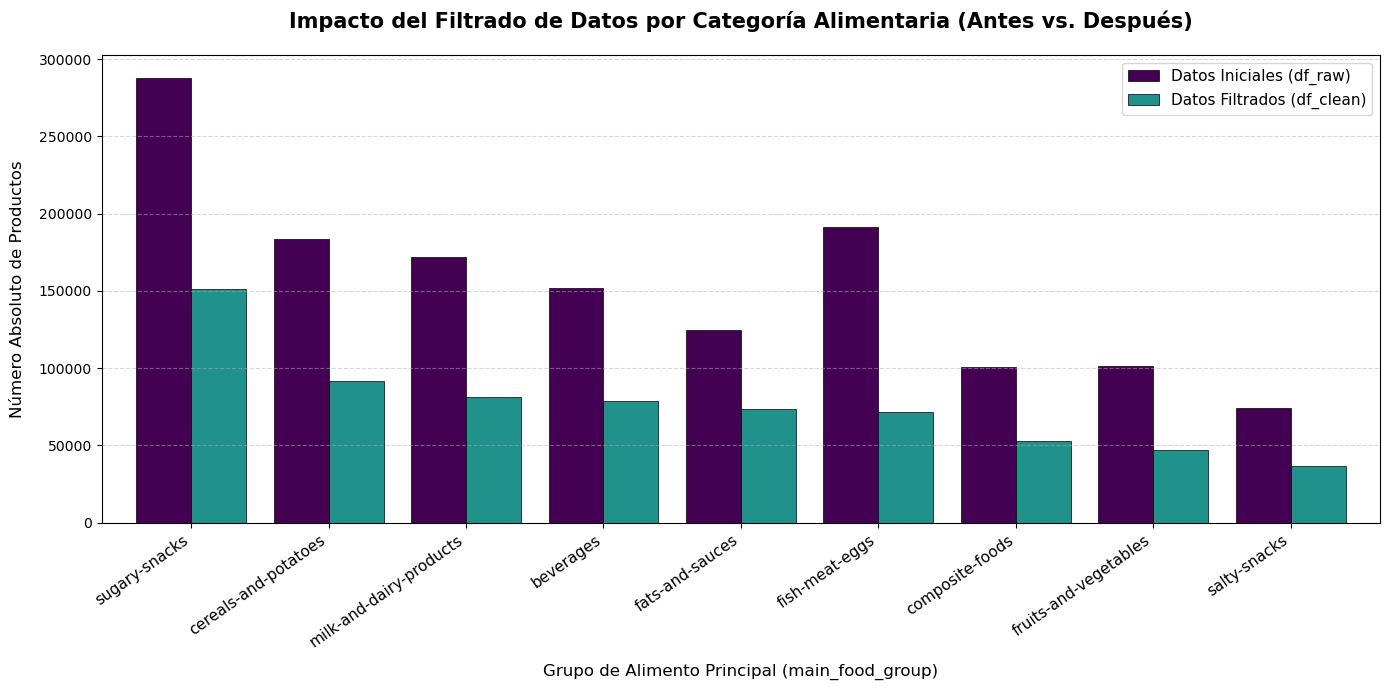

In [13]:
# ==============================================================================
# PIPELINE DE LIMPIEZA Y ANÁLISIS DE DISTRIBUCIÓN COMPARATIVA
# ==============================================================================

# 1. PREPARACIÓN DEL DATASET ORIGINAL (df_raw)
# Extraemos el grupo principal y limpiamos el prefijo para la medición inicial
df_raw['main_food_group'] = df_raw['food_groups_tags'].str[0].str.replace('en:', '', regex=False)

# Excluimos las bebidas alcohólicas y comida de bebe de todo el pipeline desde el inicio
df_raw = df_raw[
    (df_raw['main_food_group'] != 'alcoholic-beverages') & 
    (df_raw['main_food_group'] != 'baby-foods-and-milks')
].copy()

# Calculamos la distribución de frecuencias ANTES de limpiar
dist_antes = df_raw['main_food_group'].value_counts()
pct_antes = df_raw['main_food_group'].value_counts(normalize=True) * 100


# 2. CREACIÓN Y LIMPIEZA DEL DATASET DEL MODELO (df_clean)
# Creamos una copia explícita en memoria para no alterar df_raw
df_clean = df_raw.copy()

# Filtro A: Aseguramos Nutriscore válido entre 'a' y 'e'
df_clean['nutriscore_grade'] = df_clean['nutriscore_grade'].str.lower()
valores_validos_nutri = ['a', 'b', 'c', 'd', 'e']
df_clean = df_clean[df_clean['nutriscore_grade'].isin(valores_validos_nutri)].copy()

# Filtro B: Aseguramos grupo NOVA numérico y válido entre 1 y 4
df_clean['nova_group'] = pd.to_numeric(df_clean['nova_group'], errors='coerce')
df_clean = df_clean[df_clean['nova_group'].isin([1, 2, 3, 4])].copy()

# Filtro C: Tratamiento de nulos en aditivos (convertir a listas vacías)
df_clean['additives_tags'] = df_clean['additives_tags'].apply(
    lambda d: d if isinstance(d, (list, np.ndarray)) else []
)


# 3. CÁLCULO DE LA DISTRIBUCIÓN DESPUÉS DE LA LIMPIEZA
dist_despues = df_clean['main_food_group'].value_counts()
pct_despues = df_clean['main_food_group'].value_counts(normalize=True) * 100


# 4. CONSTRUCCIÓN DE LA TABLA COMPARATIVA CONSOLIDADA
df_comparativa = pd.DataFrame({
    'Cantidad Antes': dist_antes,
    '% Antes': pct_antes,
    'Cantidad Después': dist_despues,
    '% Después': pct_despues
})

# Rellenamos con 0 si alguna categoría pequeña se quedó sin registros tras filtrar
df_comparativa = df_comparativa.fillna(0)

# Calculamos el volumen absoluto de productos descartados por categoría
df_comparativa['Productos Eliminados'] = df_comparativa['Cantidad Antes'] - df_comparativa['Cantidad Después']
df_comparativa = df_comparativa.sort_values(by='Cantidad Después', ascending=False)


# 5. MOSTRAR RESULTADOS GENERALES Y TABLA FINAL
print("=======================================================")
print("             RESUMEN MÉTRICO DEL DATASET              ")
print("=======================================================")
print(f"Total productos en df_raw (sin alcohol): {len(df_raw)}")
print(f"Total productos en df_clean (filtrado) : {len(df_clean)}")
print(f"Productos sin aditivos (Grupo Control) : {sum(df_clean['additives_tags'].map(len) == 0)}")
print("=======================================================\n")

print("--- TABLA COMPARATIVA DE DISTRIBUCIÓN POR CATEGORÍA ---")
display(df_comparativa)

# 6. GENERAR EL GRÁFICO DE BARRAS AGRUPADO (ANTES VS DESPUÉS)
# Creamos la figura de forma robusta con subplots
fig, ax = plt.subplots(figsize=(14, 7))

# Extraemos solo las columnas de cantidades absolutas para graficar lado a lado
# Usamos colores corporativos/académicos de la paleta viridis
df_comparativa[['Cantidad Antes', 'Cantidad Después']].plot(
    kind='bar', 
    ax=ax, 
    color=['#440154', '#21918c'], 
    width=0.8,
    edgecolor='black',
    linewidth=0.5
)

# Personalización profunda del gráfico para asegurar legibilidad doctoral
ax.set_title('Impacto del Filtrado de Datos por Categoría Alimentaria (Antes vs. Después)', fontsize=15, weight='bold', pad=20)
ax.set_xlabel('Grupo de Alimento Principal (main_food_group)', fontsize=12, labelpad=10)
ax.set_ylabel('Número Absoluto de Productos', fontsize=12, labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Leyenda explicativa clara
ax.legend(['Datos Iniciales (df_raw)', 'Datos Filtrados (df_clean)'], fontsize=11, loc='upper right')

# Rotación e inclinación de etiquetas para evitar solapamientos o cortes de texto
plt.xticks(rotation=35, ha='right', fontsize=11)
plt.yticks(fontsize=10)

# Ajuste milimétrico de los márgenes
plt.tight_layout()

# Guardado automático en tu repositorio de figuras del bootcamp
plt.savefig('../../outputs/plots/food_products/comparacion_limpieza_categorias.png', dpi=300, bbox_inches='tight')

### 3. Ingeniería de Características (One-Hot Encoding)
Para que el modelo pueda procesar los aditivos (que vienen en formato de lista), se realiza una expansión matricial:
* **Vectorización**: Se utiliza `get_dummies()` con un separador pipe (`|`) para crear una columna individual por cada aditivo único encontrado.
* **Matriz Binaria**: El resultado es una matriz donde cada fila representa un producto y cada columna un aditivo, marcando con un **1** la presencia y con **0** la ausencia.
* El resultado se guarda en un archivo `dataset_800k_aditivos.csv`, que sirve como base para el entrenamiento de los modelos de clustering (K-Means) y el posterior análisis toxicológico.


In [14]:
# Creamos la matriz de aditivos
df_dummies = df_clean['additives_tags'].str.join('|').str.get_dummies()

# Unimos con los scores (Usamos 'product_name' que ya está limpio y aplanado)
df_final = pd.concat([
    df_clean[['code', 'product_name', 'nutriscore_grade', 'nova_group']].reset_index(drop=True), 
    df_dummies.reset_index(drop=True)
], axis=1)

# Rellenamos posibles NaNs con 0
df_final = df_final.fillna(0)

# Pasamos el nutriscore grade a numérico
nutriscore_map = {
    'a': 1,
    'b': 2,
    'c': 3,
    'd': 4,
    'e': 5
}

# Aplicar la transformación (asegurándonos de que las letras estén en minúsculas)
df_final['nutriscore_grade'] = df_final['nutriscore_grade'].str.lower().map(nutriscore_map)

# Guardamos el csv final para el modelo
df_final.to_csv('../data/dataset_800k_aditivos.csv', index=False)

### 4. Resumen Estadístico de la Muestra
Tras procesar los datos, el cuaderno genera un análisis de la densidad de la información:
* **Diversidad Química**: Se han identificado **572 tipos de aditivos** diferentes en el mercado.
* **Prevalencia**: El aditivo más frecuente es el **E-330 (Ácido Cítrico)**, presente en más de 159,000 productos.
* **Densidad**: La matriz final tiene una densidad del **0.40%**, lo que indica que es una matriz dispersa (sparse matrix) muy común en análisis de ingredientes complejos.



In [10]:
# 1. Cargar el dataset 
df = pd.read_csv('../data/dataset_800k_aditivos.csv') 

# 2. Identificar columnas de aditivos
cols_aditivos = [c for c in df.columns if c.startswith('en:e')]

# 3. Contar presencias
# Sumamos cada columna: si la suma es > 0, el aditivo existe en la muestra
conteo = df[cols_aditivos].sum()
aditivos_reales = conteo[conteo > 0].sort_values(ascending=False)

print(f"--- RESUMEN DE LA EXTRACCIÓN ---")
print(f"Total de productos analizados: {len(df)}")
print(f"Total de columnas (aditivos posibles): {len(cols_aditivos)}")
print(f"Aditivos encontrados (con al menos un '1'): {len(aditivos_reales)}")
print(f"Aditivos 'fantasma' (siempre a cero): {len(cols_aditivos) - len(aditivos_reales)}")

print(f"\n--- TOP 10 ADITIVOS MÁS FRECUENTES ---")
print(aditivos_reales.head(10))

# 4. Densidad de la matriz
total_celdas = len(df) * len(cols_aditivos)
celdas_con_uno = aditivos_reales.sum()
print(f"\nDensidad de la matriz: {(celdas_con_uno / total_celdas):.4%}")

--- RESUMEN DE LA EXTRACCIÓN ---
Total de productos analizados: 837548
Total de columnas (aditivos posibles): 572
Aditivos encontrados (con al menos un '1'): 572
Aditivos 'fantasma' (siempre a cero): 0

--- TOP 10 ADITIVOS MÁS FRECUENTES ---
en:e330      159583
en:e322      108035
en:e322i      88830
en:e500       68991
en:e415       57089
en:e471       52397
en:e412       48996
en:e500ii     46932
en:e202       46003
en:e450       36499
dtype: int64

Densidad de la matriz: 0.4019%


### 5. Exportación Final
El dataset obtenido tambíen se guarda en archivo parquet por si acaso, como segunda vía de alimentación de la apliación en Streamlit, cuando haya errores de conexion al servidor (API de openfoodfacts)

In [ ]:
# ==============================================================================
# EXPORTACIÓN DE LA BASE DE DATOS LOCAL PARA STREAMLIT (PIPELINE HÍBRIDO)
# ==============================================================================

# Creamos un dataframe ligero que conserve las claves primarias de búsqueda
df_local_streamlit = df_clean[[
    'code',               # clave de búsqueda (Código de barras)
    'product_name',     
    'nutriscore_grade',   
    'nova_group',         
    'additives_tags',     # Lista nativa de aditivos oficiales (ej: ['en:e330'])
    'ingredients_text'    # Texto de ingredientes en crudo (Por si no estuvieran todos los aditivos en los tags de aditivos)
]].copy()

# Nos aseguramos de que el código de barras no tenga espacios y sea texto puro
df_local_streamlit['code'] = df_local_streamlit['code'].astype(str).str.strip()

# Guardamos en la carpeta local de datos en formato Parquet de alto rendimiento
df_local_streamlit.to_parquet('../data/alimentos_tesis.parquet', compression='snappy', index=False)

print(f"🎉 ¡Base de datos local exportada con éxito!")
print(f"Se han indexado {len(df_local_streamlit)} productos con códigos de barras e ingredientes listos para Streamlit.")

🎉 ¡Base de datos local exportada con éxito!
Se han indexado 836897 productos con códigos de barras e ingredientes listos para Streamlit.
